In [1]:
import cv2
from ocr.tesseract  import TesseractOCR
from digitize       import Digitize
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

digitizer = Digitize(
    ocr    = TesseractOCR(),
    config = {"preprocessing": {"decide_engine": {"model_path": "models\decide_model.joblib"}}},
)

image = cv2.imread(r"data\input\preprocess\images\0080.png", 0)

result = digitizer.digitize(image)
print(result.ocr)

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\kunnic\AppData\Local\Temp\ipykernel_3248\53982031.py:9: SyntaxWarning: invalid escape sequence '\d'
  config = {"preprocessing": {"decide_engine": {"model_path": "models\decide_model.joblib"}}},


 OCR INFERENCE RESULT 
 Total Blocks : 71
 Avg Conf     : 0.6989
--------------------------------------------------
 [00] [Conf: 0.7050] "ỦYBANNHÂNDÂN `" | Box: (113, 20, 231, 32)
 [01] [Conf: 0.7871] ".- .CỌNGHOÀXÃ HỘI CHỦ NGHĨA VIỆT NAM" | Box: (77, 30, 776, 39)
 [02] [Conf: 0.7025] ".HUYỆN LƯƠNG TÀI "`..." | Box: (102, 53, 327, 29)
 [03] [Conf: 0.8443] "Độc lập ='Tự đo - Hạnh phúc" | Box: (482, 65, 283, 29)
 [04] [Conf: 0.2700] "ˆ" | Box: (323, 105, 8, 12)
 [05] [Conf: 0.1860] "Số: Á0K./QĐ-UỜND ` ` 4" | Box: (116, 101, 593, 53)
 [06] [Conf: 0.1888] ""Lương 7ài ngày 03 thẳng lãm 20242 `." | Box: (426, 117, 456, 33)
 [07] [Conf: 0.8357] "Y#v thu bồi, hãy bỏ Quyết số" | Box: (130, 187, 334, 41)
 [08] [Conf: 0.9500] "định 1328/QĐ-UBND ngày 10/11/2023" | Box: (395, 201, 396, 31)
 [09] [Conf: 0.8417] "của UBND huyện về việc Đồ" | Box: (145, 217, 377, 40)
 [10] [Conf: 0.9400] "phê duyệt án Điều chỉnh quy hoạch" | Box: (397, 225, 377, 35)
 [11] [Conf: 0.6711] "._ S6 Cụm công nghiệp Lâm Bình

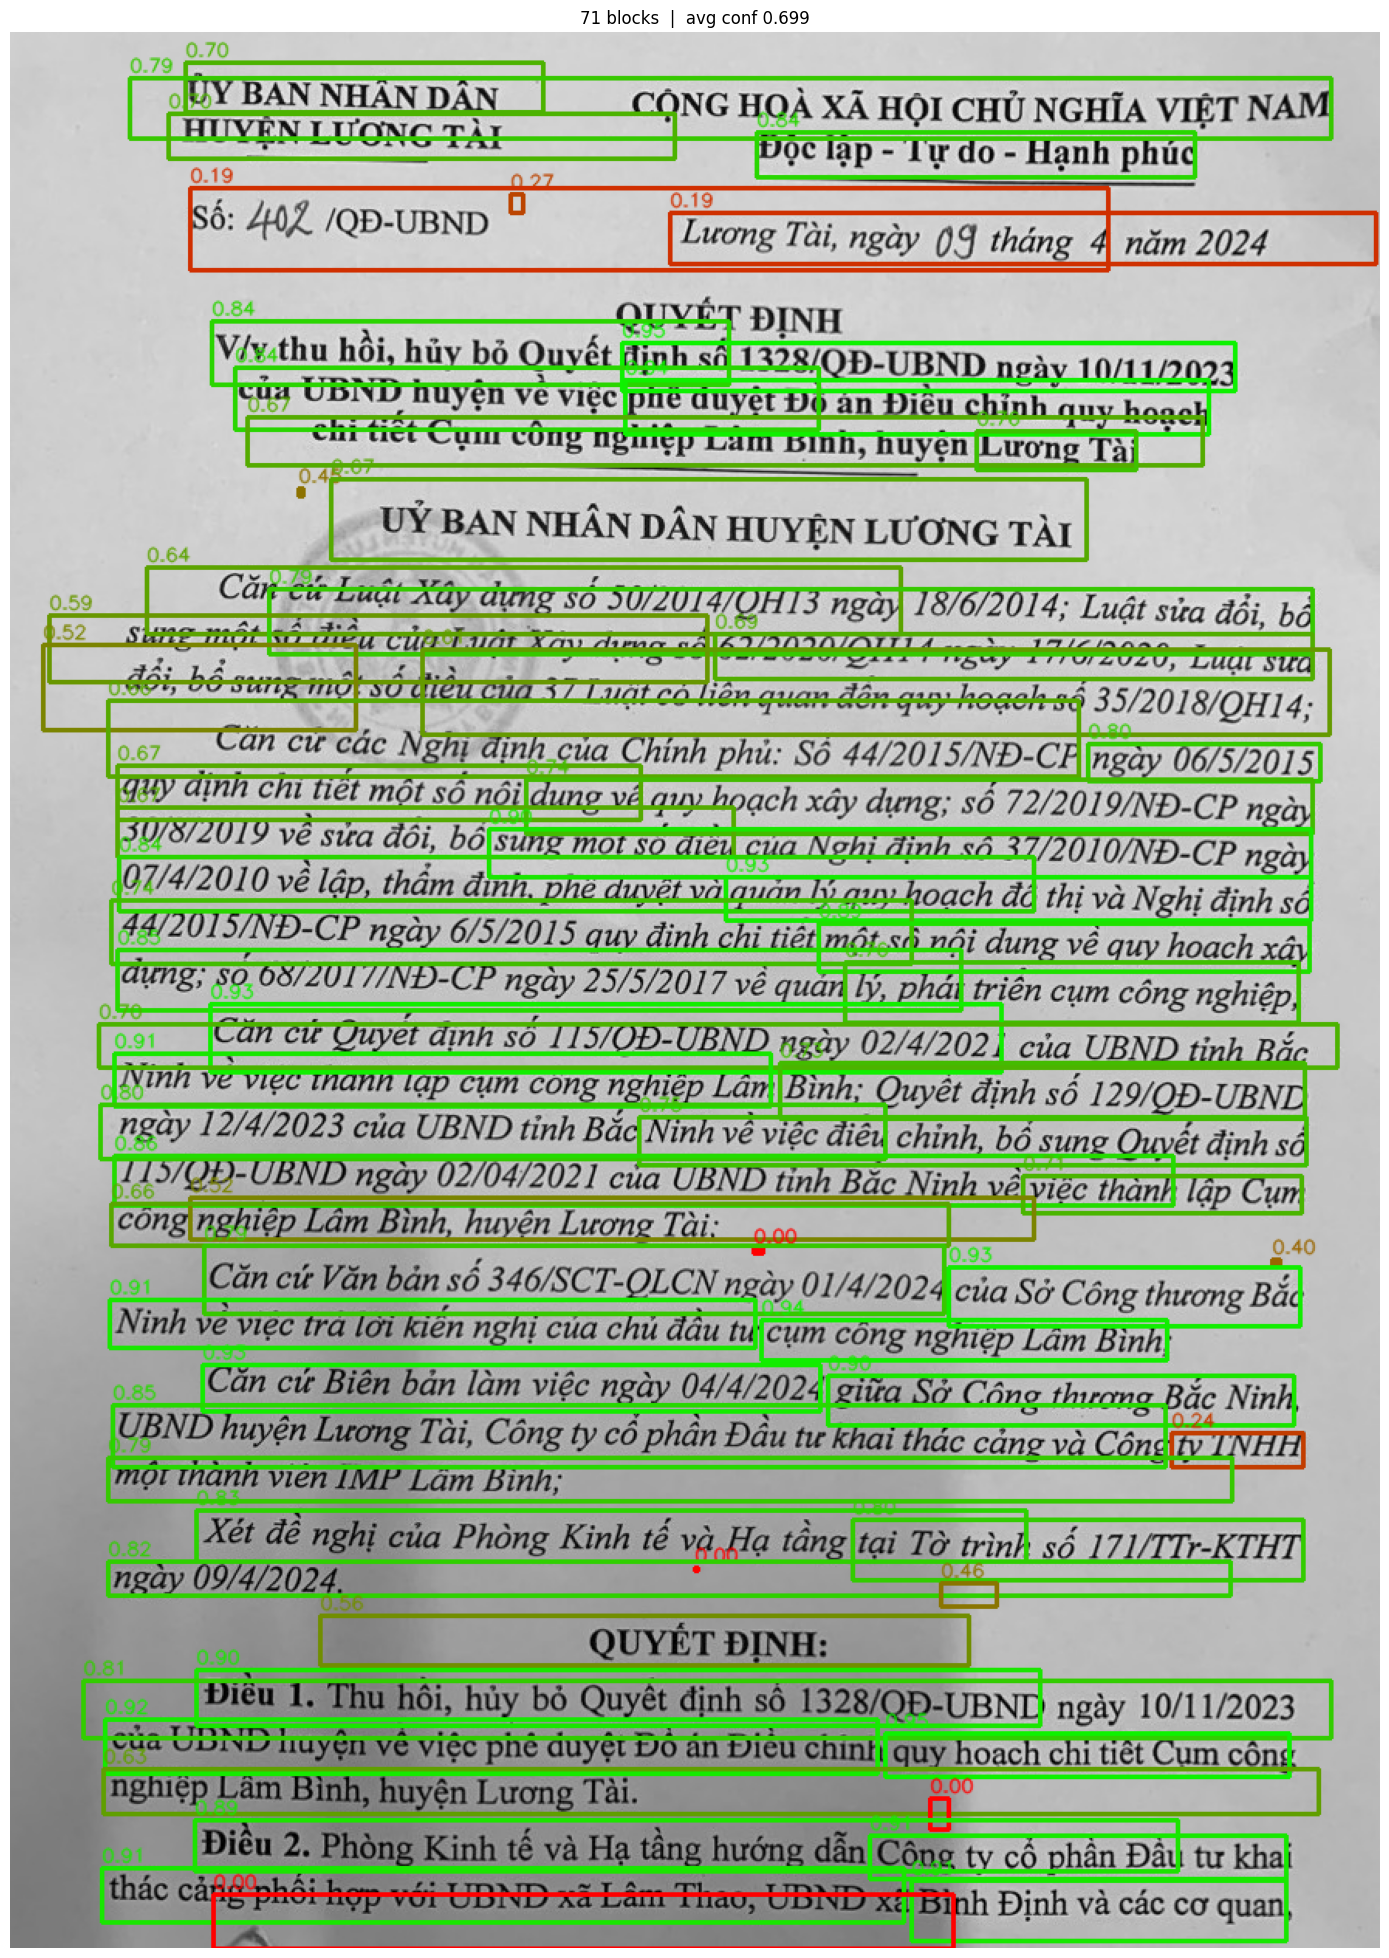

In [5]:
import matplotlib.pyplot as plt

blocks = result.ocr.texts

# ── draw ──────────────────────────────────────────────────────────────
canvas = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

for block in blocks:
    if isinstance(block.bounding_polygon, list) and len(block.bounding_polygon) >= 2:
        x, y, w, h = block.bounding_box()

        # colour: green → high conf, red → low conf
        g = int(block.confidence * 255)
        r = 255 - g
        color = (r, g, 0)

        cv2.rectangle(canvas, (x, y), (x + w, y + h), color, 2)
        cv2.putText(
            canvas,
            f"{block.confidence:.2f}",
            (x, y - 4),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4, color, 1,
            cv2.LINE_AA,
        )

plt.figure(figsize=(14, 20))
plt.imshow(canvas)
plt.axis("off")
plt.title(f"{len(blocks)} blocks  |  avg conf {result.ocr.confidence:.3f}")
plt.tight_layout()
plt.show()